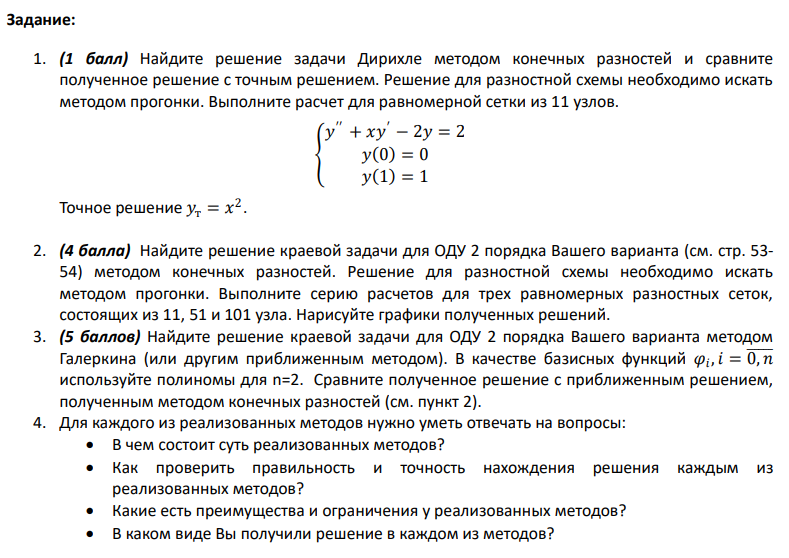  
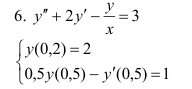

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Коэффициенты уравнения y'' + p(x)·y' + q(x)·y = f(x)
def p(x):
    return 2.0        # коэф. при y'

def q(x):
    return -1.0 / x   # коэф. при y  (из члена -y/x)

def f(x):
    return 3.0        # правая часть

# Границы отрезка
a = 0.2
b = 0.5

# Левое ГУ — Дирихле: y(0.2) = 2
mu1 = 2.0

# Правое ГУ — Робена: 0.5·y(0.5) − y'(0.5) = 1
# Запись: beta_r·y(b) + gamma_r·y'(b) = mu2
beta_r  =  0.5   # коэф. при y(b)
gamma_r = -1.0   # коэф. при y'(b)
mu2     =  1.0


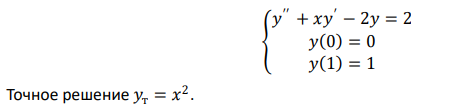
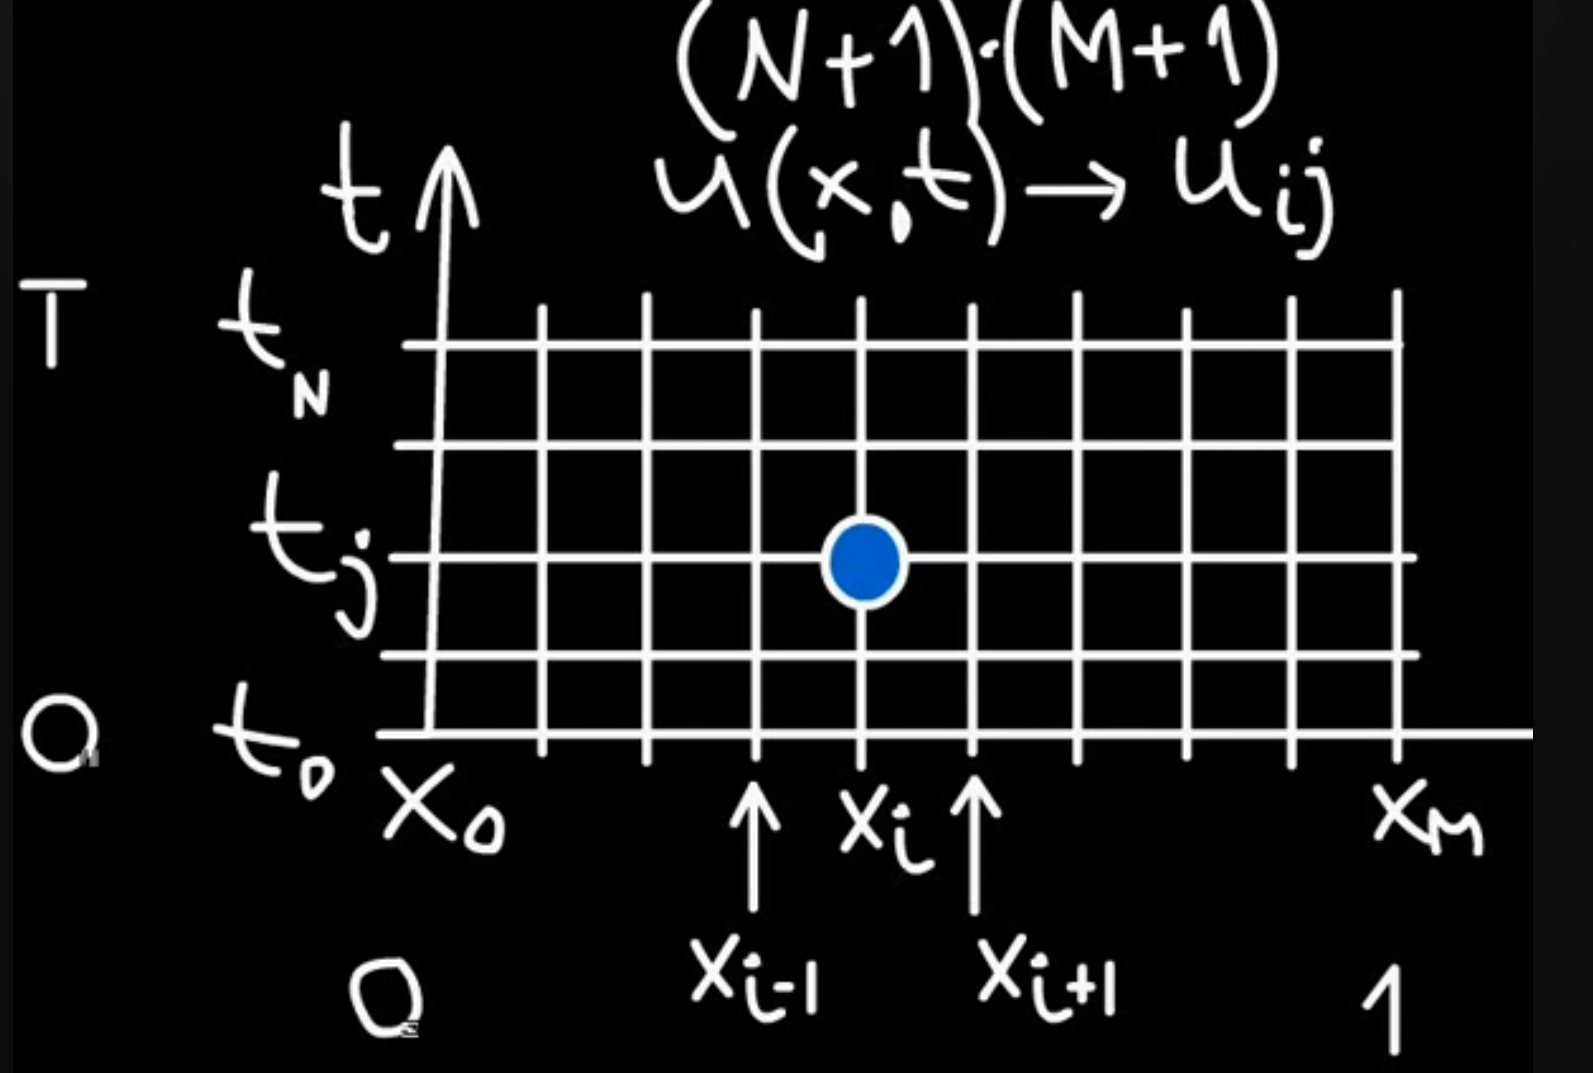

Аппроксимация производных: https://youtu.be/s4JQouWccDk?si=M9Dq52Q2zcdRb4r6

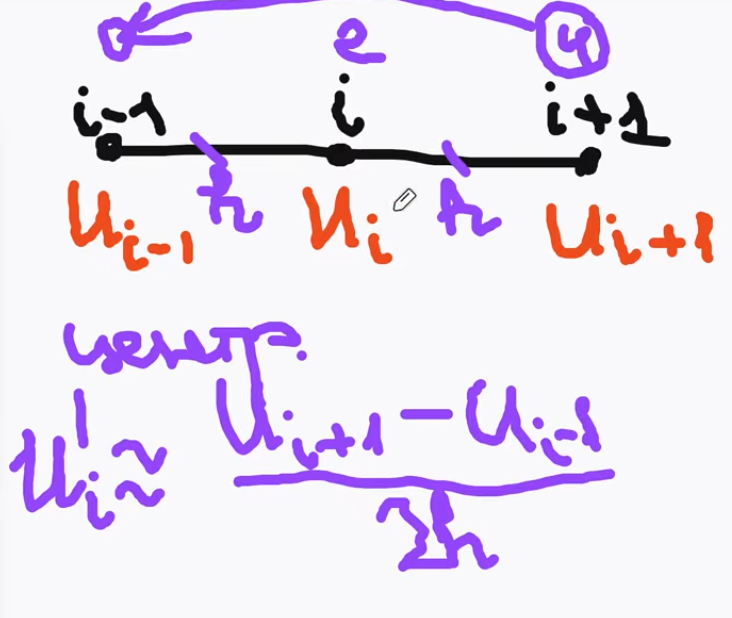

Наше ур-е
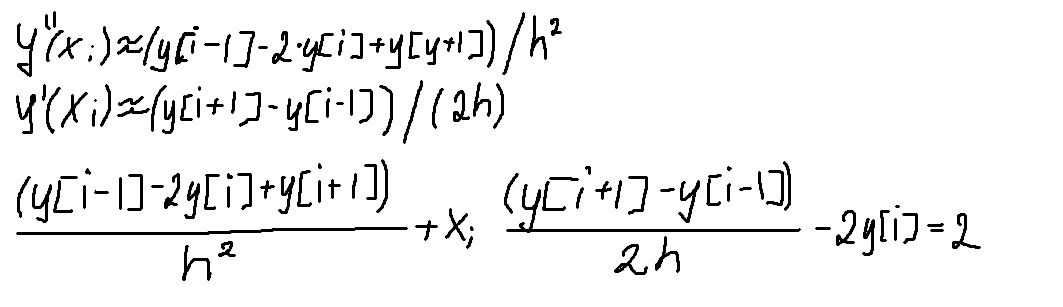

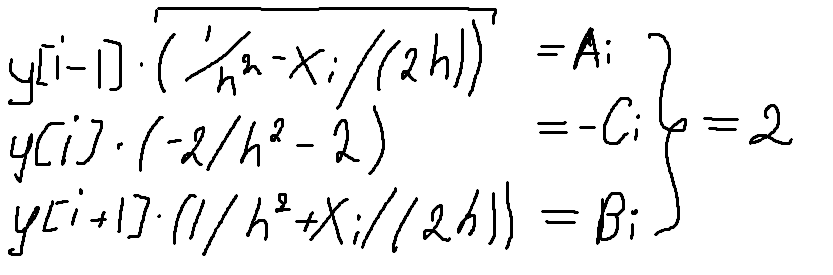
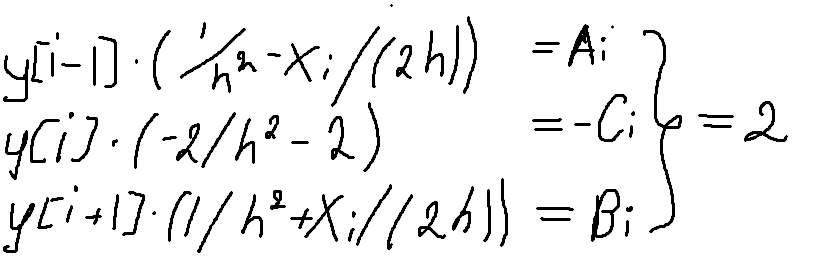

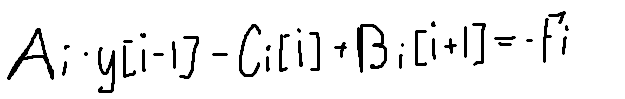

Это трёхдиагональная СЛАУ — решается методом прогонки

Прогонка - представляетсярешением в виде y[i] = ξ[i]·y[i+1] + η[i] (но у нас это xi и eta) и выводим рекуррентные формулы. На первом шаге учитываем ГУ y[0] = μ₁

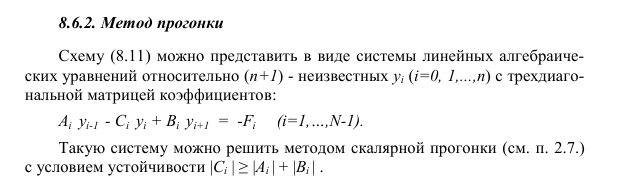

Задание 1: y'' + x*y' - 2y = 2,  метод прогонки, n = 11

  i |   x_i |       y_числ |       y_точн |         |Δy|
------------------------------------------------------
  0 |  0.00 |   0.00000000 |   0.00000000 |     0.00e+00
  1 |  0.10 |   0.01000000 |   0.01000000 |     4.51e-17
  2 |  0.20 |   0.04000000 |   0.04000000 |     9.02e-17
  3 |  0.30 |   0.09000000 |   0.09000000 |     1.39e-16
  4 |  0.40 |   0.16000000 |   0.16000000 |     1.67e-16
  5 |  0.50 |   0.25000000 |   0.25000000 |     1.39e-16
  6 |  0.60 |   0.36000000 |   0.36000000 |     2.22e-16
  7 |  0.70 |   0.49000000 |   0.49000000 |     1.67e-16
  8 |  0.80 |   0.64000000 |   0.64000000 |     1.11e-16
  9 |  0.90 |   0.81000000 |   0.81000000 |     0.00e+00
 10 |  1.00 |   1.00000000 |   1.00000000 |     0.00e+00

Макс. погрешность: 2.2204e-16


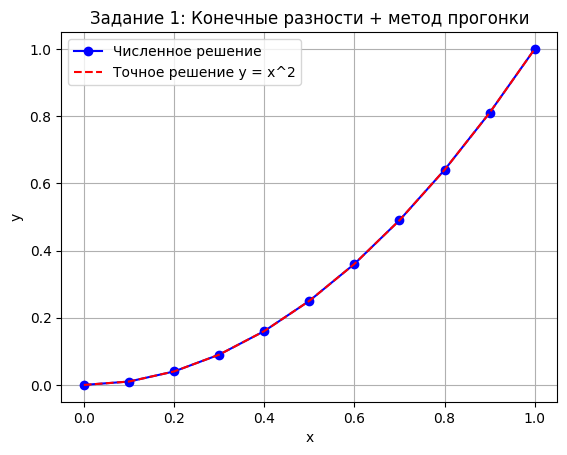

In [16]:
def solve_task1():
    # y'' + x*y' - 2y = 2,  y(0) = 0,  y(1) = 1
    # Точное решение: y = x^2
    # Схема: центральные разности, решение — метод прогонки

    n = 11                      # число узлов
    h = 1.0 / (n - 1)           # шаг сетки: h = (b-a)/(n-1) = 1/10 = 0.1

    # Узлы сетки: x[0]=0.0, x[1]=0.1, ..., x[10]=1.0
    x = [i * h for i in range(n)]

    # Из условия
    mu1 = 0.0   # y(0) = 0  — левое ГУ Дирихле
    mu2 = 1.0   # y(1) = 1  — правое ГУ Дирихле

    # Разностная схема для каждого внутреннего узла i = 1,...,n-2:
    #   A_i * y[i-1] - C_i * y[i] + B_i * y[i+1] = -F_i
    # Коэффициенты из аппроксимации y'' + x*y' - 2y = 2:
    #   A_i = 1/h^2 - x[i]/(2h)
    #   C_i = 2/h^2 + 2
    #   B_i = 1/h^2 + x[i]/(2h)
    #   F_i = -2
    #
    # Условие устойчивости прогонки: |C_i| >= |A_i| + |B_i|
    #   2/h^2 + 2  >=  2/h^2

    # Прогоночные коэффициенты xi и eta
    # Смысл: y[i] = xi[i] * y[i+1] + eta[i]
    xi  = [0.0] * n
    eta = [0.0] * n

    # Прямой ход, начало (i = 1):
    # Для i=1 нет предыдущих xi/eta, поэтому используем ГУ y[0] = mu1
    A1 = 1/h**2 - x[1] / (2*h)
    C1 = 2/h**2 + 2.0
    B1 = 1/h**2 + x[1] / (2*h)
    F1 = -2.0
    xi[1]  = B1 / C1
    eta[1] = (F1 + A1 * mu1) / C1

    # Прямой ход: i = 2, ..., n-2
    for i in range(2, n - 1):
        Ai = 1/h**2 - x[i] / (2*h)
        Ci = 2/h**2 + 2.0
        Bi = 1/h**2 + x[i] / (2*h)
        Fi = -2.0
        denom  = Ci - Ai * xi[i - 1]       # знаменатель рекуррентной формулы
        xi[i]  = Bi / denom
        eta[i] = (Fi + Ai * eta[i - 1]) / denom

    # Обратный ход: y[i] = xi[i] * y[i+1] + eta[i]
    y = [0.0] * n
    y[0]     = mu1      # левое ГУ
    y[n - 1] = mu2      # правое ГУ
    for i in range(n - 2, 0, -1):
        y[i] = xi[i] * y[i + 1] + eta[i]

    # Точное решение y = x^2
    y_exact = [x[i]**2 for i in range(n)]

    # Таблица результатов
    print("Задание 1: y'' + x*y' - 2y = 2,  метод прогонки, n =", n)
    print(f"\n{'i':>3} | {'x_i':>5} | {'y_числ':>12} | {'y_точн':>12} | {'|Δy|':>12}")
    print("-" * 54)
    for i in range(n):
        err = abs(y[i] - y_exact[i])
        print(f"{i:>3} | {x[i]:>5.2f} | {y[i]:>12.8f} | {y_exact[i]:>12.8f} | {err:>12.2e}")
    max_err = max(abs(y[i] - y_exact[i]) for i in range(n))
    print(f"\nМакс. погрешность: {max_err:.4e}")

    plt.figure()
    plt.plot(x, y,       'bo-', label='Численное решение')
    plt.plot(x, y_exact, 'r--', label='Точное решение y = x^2')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Задание 1: Конечные разности + метод прогонки')
    plt.legend()
    plt.grid()
    plt.show()

solve_task1()


# Уравнение с граничными условиями Робина и Дирихле

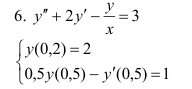

Дирихле - задаем значение ф-ции на границе</br>
Нейман - значение производной на границе</br>
Робин - смешанное, линейная комбинация значения и производной
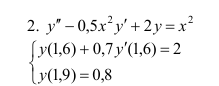

Есть 3 формулы для аппроксимации производной</br>
Первый</br>
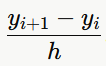</br>
Последний</br>
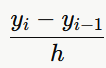</br>
Центральный</br>
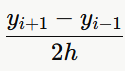</br>

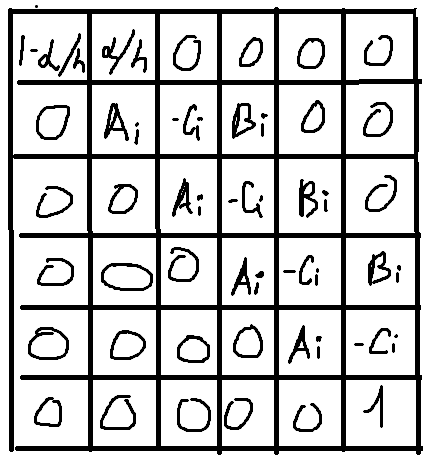
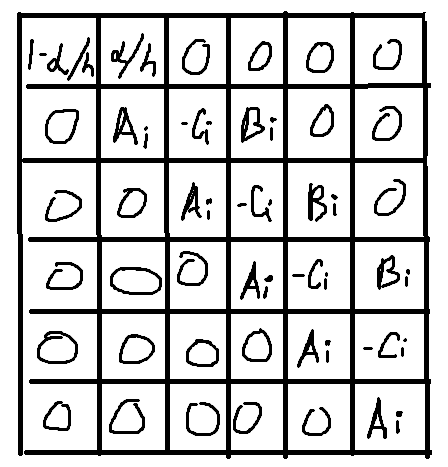

при n=11
y = [2.         1.90330824 1.82210117 1.75436953 1.6984908  1.65312637
 1.61715298 1.58961502 1.56969034 1.55666489 1.5499136 ]
при n=51
y = [2.         1.97837467 1.95745834 1.93722927 1.91766686 1.89875151
 1.88046457 1.86278826 1.84570562 1.82920043 1.81325718 1.79786104
 1.78299777 1.76865373 1.75481582 1.74147144 1.72860849 1.71621532
 1.70428069 1.69279379 1.68174419 1.67112182 1.66091695 1.65112019
 1.64172246 1.63271496 1.62408921 1.61583695 1.60795022 1.60042128
 1.59324264 1.58640703 1.57990738 1.57373684 1.56788877 1.56235669
 1.55713431 1.55221554 1.54759442 1.54326518 1.53922218 1.53545995
 1.53197315 1.52875659 1.5258052  1.52311405 1.52067832 1.51849333
 1.51655449 1.51485735 1.51339754]
при n=101
y = [2.         1.98903979 1.97825998 1.96765774 1.95723033 1.94697505
 1.9368893  1.92697053 1.91721625 1.90762404 1.89819153 1.88891643
 1.87979647 1.87082946 1.86201325 1.85334574 1.84482488 1.83644866
 1.82821511 1.82012233 1.81216842 1.80435156 1.79666994 1.789121

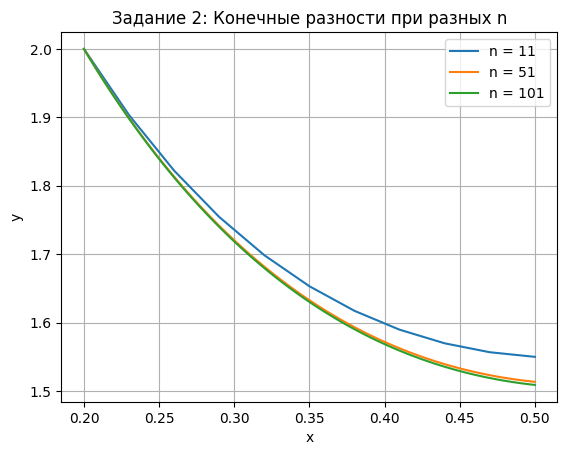


Максимальная разница между решениями при разных n:
     x        n=11        n=51       n=101      max_diff
--------------------------------------------------------
  0.20    2.000000    2.000000    2.000000  7.0033e-13
  0.25    1.849170    1.840204    1.839241  9.9295e-03
  0.30    1.735743    1.720346    1.718556  1.7187e-02
  0.35    1.653126    1.632715    1.630194  2.2932e-02
  0.40    1.598794    1.571787    1.568527  3.0267e-02
  0.45    1.565349    1.533135    1.529215  3.6133e-02
  0.50    1.549914    1.513398    1.508878  4.1035e-02


In [17]:
def finite_difference(n):
    x1, x2 = a, b     # [0.2, 0.5] из условия варианта
    h = (x2 - x1) / (n - 1)
    x = np.linspace(x1, x2, n)   # n равномерных узлов

    A     = np.zeros((n, n))  # матрица коэффициентов n×n
    b_vec = np.zeros(n)       # вектор правой части

    # Внутренние узлы i=1,...,n-2 — схема центральных разностей:
    # A[i,i-1]*y[i-1] + A[i,i]*y[i] + A[i,i+1]*y[i+1] = b_vec[i]
    for i in range(1, n - 1):
        pi = p(x[i])                           # p(xᵢ) = 2
        A[i, i - 1] = 1/h**2 - pi / (2*h)     # коэф. при y[i-1]
        A[i, i]     = -2/h**2 + q(x[i])        # коэф. при y[i]
        A[i, i + 1] = 1/h**2 + pi / (2*h)      # коэф. при y[i+1]
        b_vec[i]    = f(x[i])                   # правая часть = 3

    # Левое ГУ — Дирихле: y(0.2) = 2
    # Строка матрицы: 1·y[0] = mu1
    A[0, 0]  = 1.0
    b_vec[0] = mu1    # = 2

    # Правое ГУ — Робена: 0.5·y(0.5) − y'(0.5) = 1
    # Аппроксимируем y'(b) левой разностью: y' ≈ (y[n-1] − y[n-2]) / h
    # Подставляем: beta_r·y[n-1] + gamma_r·(y[n-1]−y[n-2])/h = mu2
    # Группируем:  y[n-2]·(−gamma_r/h) + y[n-1]·(beta_r + gamma_r/h) = mu2
    A[n-1, n-2] = -gamma_r / h                   # коэф. при y[n-2]
    A[n-1, n-1] =  beta_r + gamma_r / h          # коэф. при y[n-1]
    b_vec[n-1]  =  mu2                            # = 1

    # np.linalg.solve — решает систему A·y = b_vec методом LU-разложения
    y = np.linalg.solve(A, b_vec)
    return x, y


n_values = [11, 51, 101]

plt.figure()
for n in n_values:
    x, y = finite_difference(n)
    print(f"при n={n}")
    print(f"y = {y}")
    plt.plot(x, y, label=f'n = {n}')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Задание 2: Конечные разности при разных n')
plt.legend()
plt.grid()
plt.show()

# --- Сравнение сходимости ---
print("\nМаксимальная разница между решениями при разных n:")

# Контрольные точки на отрезке [0.2, 0.5] с шагом 0.05
x_check = [0.2 + i * 0.05 for i in range(7)]  # [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

results_per_n = {}
for n in n_values:
    xn, yn = finite_difference(n)
    # Интерполяция — приводим разные сетки к общим контрольным точкам
    results_per_n[n] = np.interp(x_check, xn, yn)

header = f"{'x':>6}" + "".join(f"  {'n='+str(n):>10}" for n in n_values) + f"  {'max_diff':>12}"
print(header)
print("-" * len(header))
for i, xval in enumerate(x_check):
    vals = [results_per_n[n][i] for n in n_values]
    # max_diff близкое к нулю → метод сошёлся
    max_diff = max(vals) - min(vals)
    row = f"{xval:6.2f}" + "".join(f"  {results_per_n[n][i]:10.6f}" for n in n_values) + f"  {max_diff:.4e}"
    print(row)


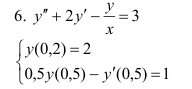

В отличие от конечных разностей, где ищем значения y[i] в узлах, Галеркин ищет ф-цию целиком в виде линейной комбинации базисных ф-ций. <br/>
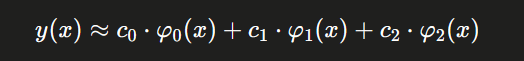

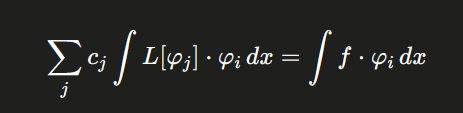


Коэффициенты c: [ 2.862189 -5.321787  5.054211]
  y(0.2)                   = 2.00000000  (должно 2.0) → OK — ГУ выполнено
  0.5·y(0.5) − y'(0.5)    = 1.00000000  (должно 1.0) → OK — ГУ выполнено

Невязка max|L[y]−f|: 9.4918e+00

Коэффициенты c: [   3.402124  -12.444549   44.244111 -131.704653  322.049185 -566.793358
  658.878176 -450.345954  136.741995]
  y(0.2)                   = 2.00000000  (должно 2.0) → OK — ГУ выполнено
  0.5·y(0.5) − y'(0.5)    = 1.00000000  (должно 1.0) → OK — ГУ выполнено

Невязка max|L[y]−f|: 2.9881e-03


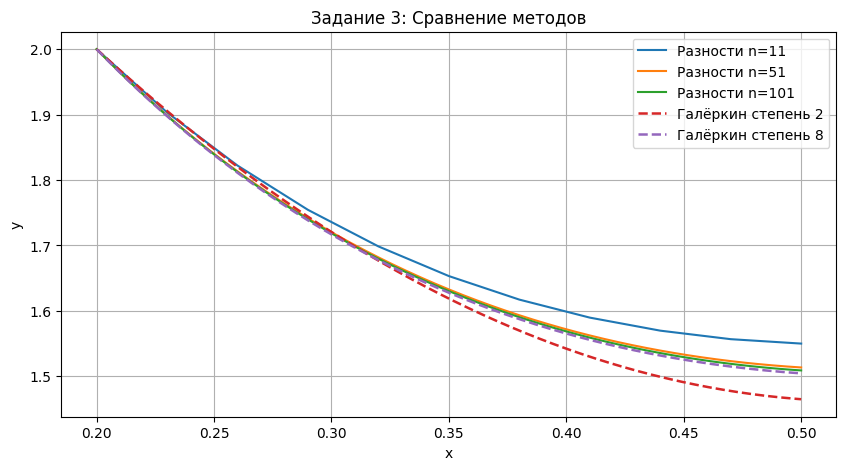

In [ ]:
def galerkin(degree=2):
    # Метод Галёркина: ищем решение в виде y(x) ≈ c₀·φ₀ + c₁·φ₁ + ... + cₙ·φₙ
    x1, x2 = a, b   # [0.2, 0.5]
    N = degree + 1   # количество базисных функций

    # Базисные функции φₖ(x) = xᵏ и их производные
    phi   = [lambda x, k=k: x**k                               for k in range(N)]
    dphi  = [lambda x, k=k: k * x**(k-1) if k > 0 else 0.0       for k in range(N)]
    ddphi = [lambda x, k=k: k*(k-1) * x**(k-2) if k > 1 else 0.0 for k in range(N)]

    # Матрица Галёркина A и вектор правой части b_vec
    # A[i][j] = ∫ L[φⱼ]·φᵢ dx,  L[u] = u'' + p(x)·u' + q(x)·u
    # b_vec[i] = ∫ f(x)·φᵢ dx
    A     = np.zeros((N, N))
    b_vec = np.zeros(N)

    for i in range(N):
        for j in range(N):
            # Применяем оператор L к φⱼ, умножаем на φᵢ и интегрируем
            integrand = lambda x, i=i, j=j: (
                ddphi[j](x) + p(x) * dphi[j](x) + q(x) * phi[j](x)
            ) * phi[i](x)
            A[i][j] = quad(integrand, x1, x2)[0]

        # Правая часть: ∫ f(x)·φᵢ dx
        rhs_fn = lambda x, i=i: f(x) * phi[i](x)
        b_vec[i] = quad(rhs_fn, x1, x2)[0]

    # Граничные условия

    # Строка 0 → левое ГУ Дирихле: y(0.2) = 2
    # Уравнение: Σ cⱼ·φⱼ(0.2) = mu1
    A[0]     = [phi[j](x1) for j in range(N)]
    b_vec[0] = mu1

    # Строка 1 → правое ГУ Робена: 0.5·y(0.5) − y'(0.5) = 1
    # Уравнение: Σ cⱼ·(beta_r·φⱼ(0.5) + gamma_r·φⱼ'(0.5)) = mu2
    A[1]     = [beta_r * phi[j](x2) + gamma_r * dphi[j](x2) for j in range(N)]
    b_vec[1] = mu2

    # Решаем систему → находим коэффициенты c₀, c₁, c₂
    coeffs = np.linalg.solve(A, b_vec)

    # Итоговое решение и его производные
    def y_sol(x):   return sum(coeffs[k] * phi[k](x)   for k in range(N))
    def dy_sol(x):  return sum(coeffs[k] * dphi[k](x)  for k in range(N))
    def ddy_sol(x): return sum(coeffs[k] * ddphi[k](x) for k in range(N))

    # Проверка граничных условий
    left_val  = y_sol(x1)                          # должно быть = mu1 = 2
    right_val = beta_r * y_sol(x2) + gamma_r * dy_sol(x2)  # должно быть = mu2 = 1
    print(f"\nКоэффициенты c: {np.round(coeffs, 6)}")
    print(f"  y(0.2)                   = {left_val:.8f}  (должно {mu1}) → {'OK — ГУ выполнено' if abs(left_val - mu1) < 1e-8 else 'НЕ ОК'}")
    print(f"  0.5·y(0.5) − y'(0.5)    = {right_val:.8f}  (должно {mu2}) → {'OK — ГУ выполнено' if abs(right_val - mu2) < 1e-8 else 'НЕ ОК'}")

    # Невязка: r(x) = y''(x) + p(x)·y'(x) + q(x)·y(x) - f(x)
    # если решение точное → r(x) = 0
    m = 200
    step = (x2 - x1) / (m - 1)
    x_res     = [x1 + i * step for i in range(m)]
    residuals = [ddy_sol(xi) + p(xi)*dy_sol(xi) + q(xi)*y_sol(xi) - f(xi) for xi in x_res]
    print(f"\nНевязка max|L[y]−f|: {max(abs(r) for r in residuals):.4e}")

    x_plot = [x1 + i * step for i in range(m)]
    y_plot = [y_sol(xi) for xi in x_plot]
    return x_plot, y_plot


# График: сравниваем конечные разности и Галёркин
plt.figure(figsize=(10, 5))

for n in [11, 51, 101]:
    x, y = finite_difference(n)
    plt.plot(x, y, label=f'Разности n={n}')

for deg in [2, 8]:
    xg, yg = galerkin(degree=deg)
    plt.plot(xg, yg, '--', linewidth=1.8, label=f'Галёркин степень {deg}')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Задание 3: Сравнение методов')
plt.legend()
plt.grid()
plt.show()


Квадратичного полинома недостаточно для точного приближения решения данного уравнения.
Базис φₖ = xᵏ при малой степени не может точно описать форму кривой. При увеличении степени до 8 метод Галёркина сходится к тому же результату что и конечные разности — оба метода решают одно и то же уравнение, просто разными математическими инструментами